# Управление и детектив (ДЗ, Часть 2)

Севрюков Никита 232

Для проверяющего:

Оценка: ?? из 50

Общий итог по двум частям: ?? из 100

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
#all imports here, pls
from scipy import stats
import pandas as pd

## Исследуем простые модели (10 баллов)



По традиции разминка, прежде чем переходить к технически сложным вещам.

### Наблюдение за константой

Исторически фильтр Калмана (и байесовские фильтры вообще) давно применяют для оценок параметров в различных моделях. Посмотрим как этот подход работает в самом простом случае. Предположим, что всё одномерное.

Мы наняли работника с условным навыком $Y_1$, который не меняется во времени. Работник должен в команде писать код, успешность которого за день измеряется прогрессом. Дневной прогресс $X_t$ (может быть отрицательным, когда мы думаем, чему мы научились) зависит от того, как в целом команда работает, и от уровня нового работника. Он может выкладываться на полную мощность, а может наоборот раздражать всех и сбивать прогресс. Наверняка мы не знаем. Как можно понять, насколько хороший работник? Конечно, дать ему поработать и посмотреть на результат.

Единственная проблема: мы наблюдаем только прогресс, который естественно зависит не только от самого работника и тем самым сильно зашумлён.

Если формально, то данная модель может выглядеть как-то так:

$$
Y_{t+1} = Y_t, \quad X_{t+1} = a Y_{t+1} + W_{t+1}, \quad Y_{1} \sim N(\mu, \sigma_1^2), \quad W_t \sim N(0, \sigma_x^2).
$$

Мы наблюдаем $X_1,..,X_n$, хотим оценить $Y_1,..,Y_n$. Возможно, вы увидели знакомую задачу, она раньше уже встречалась.

В этом примере по сути латентной динамики никакой нет -- мы наблюдаем за константой, поэтому всё предельно просто. Механизм оценки мы будем строить на основе фильтрации Калмана, который должен оценить

$$
\hat{Y}_t = \mathbb{E}\left[ Y_t ~\vert~ X_1,..,X_t \right]
$$

и ковариацию ошибки

$$
P_t = \mathbb{E}\left[ (Y_t-\hat{Y}_t)(Y_t-\hat{Y}_t)^T ~\vert~ X_1,..,X_t \right].
$$

Всё это -- апостериорная байесовская оценка параметра $Y_1$.

Выпишите уравнения фильтрации для этой задачи в поле ниже.

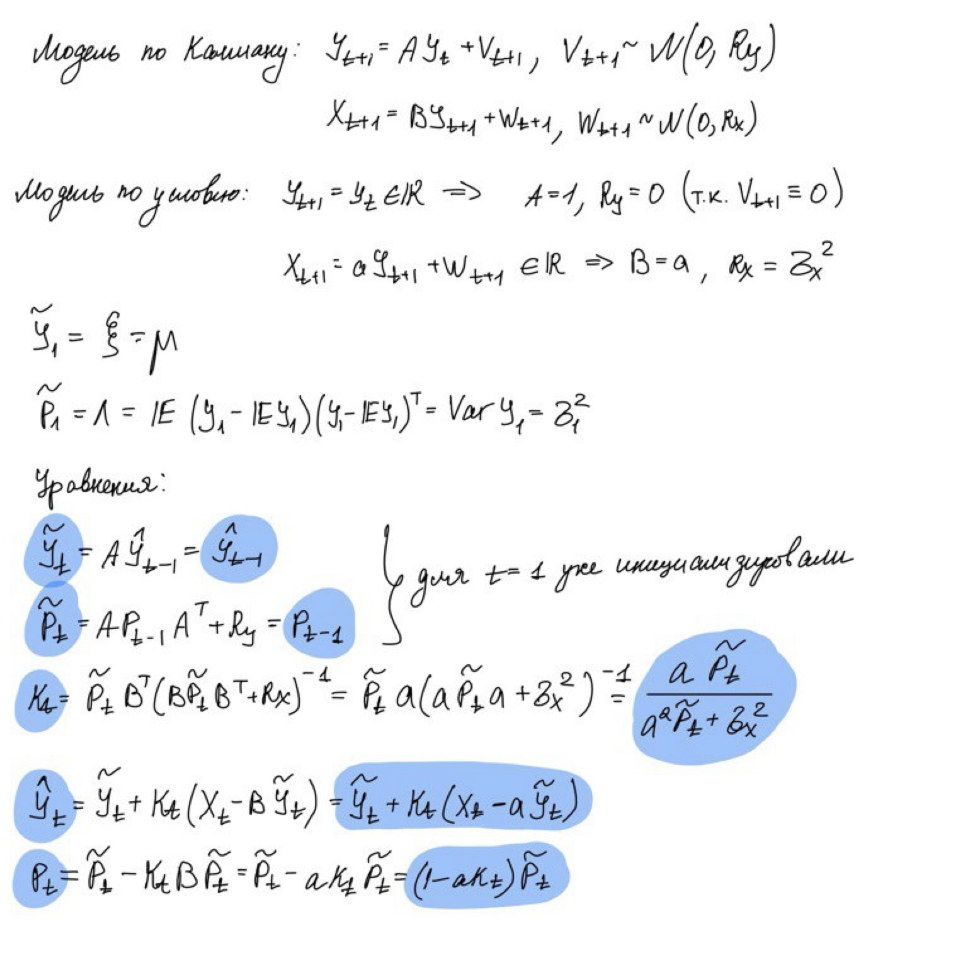

А теперь посмотрим, как это работает. Сойдётся ли оценка к реальному значению?

In [ ]:
def constFiltering(xs, a, mu, sigma1, sigmax):
    """Filters the observations of one constant

    Args:
        xs (float[]): observation (T,)
        a (float): worker output
        mu (float): apriori mean of the skill
        sigma1 (float): apriori variance of the skill (sigma^2)
        sigmax (float): observation variance (sigma^2)

    Returns:
        yhats, Ps: estimations and aposteriori (filtering) uncertainties
    """
    y_hats = np.zeros_like(xs)
    p = np.zeros_like(xs)

    for t in range(xs.shape[0]):
        if t == 0:
            y_tilda = mu
            p_tilda = sigma1
        else:
            y_tilda = y_hats[t - 1]
            p_tilda = p[t - 1]
        k = a * p_tilda / (a * a * p_tilda + sigmax)
        y_hats[t] = y_tilda + k * (xs[t] - a * y_tilda)
        p[t] = (1 - a * k) * p_tilda

    return y_hats, p


Если вы уже успели приглядеться к формулам, пока писаои фильтрацию, то могли заметить, что вычисление апостериорного прогнооза, фильтра и априорной ковариации -- это лишь технические промежуточные шаги, которые просто могут быть напрямую встроены в формулы.

Положим, что эффективность работника $Y_t$ -- это такой параметр, что работник сам один производит $2Y_t$ прогресса. Сгенерируем выборку наблюдений:

In [ ]:
def constSimulation(mu,sigma1,a,sigmax,N=100):
    trueEfficiency = mu+ np.sqrt(sigma1)*np.random.standard_normal()
    return trueEfficiency, a*trueEfficiency + np.random.standard_normal(size=(N,))*np.sqrt(sigmax)

mu=0.2
sigma1=0.5
sigmax=0.6
N=100
a=2
trueEff, xs = constSimulation(mu,sigma1,a,sigmax,N=N)

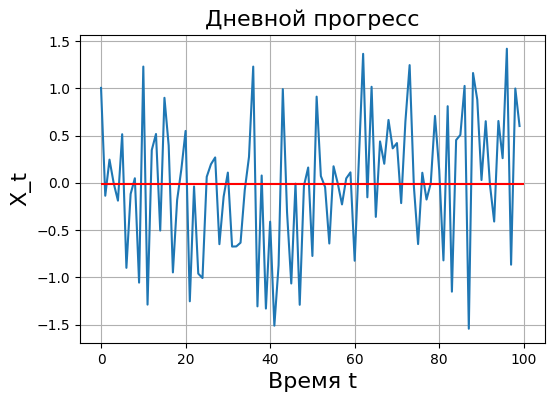

In [ ]:
f, ax = plt.subplots(figsize=(6,4))

ax.grid()
ax.set_title("Дневной прогресс", fontsize=16)
ax.set_ylabel("X_t", fontsize=16)
ax.set_xlabel("Время t", fontsize=16)
ax.plot(xs)
ax.hlines(y=trueEff, xmin=0, xmax=N, colors="red")

Применим фильтр....

In [ ]:
yhats, Ps = constFiltering(xs,a,mu,sigma1,sigmax) #и???

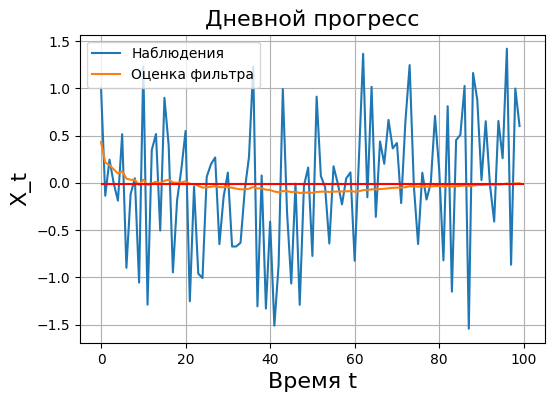

In [ ]:
f, ax = plt.subplots(figsize=(6,4))

ax.grid()
ax.set_title("Дневной прогресс", fontsize=16)
ax.set_ylabel("X_t", fontsize=16)
ax.set_xlabel("Время t", fontsize=16)
ax.plot(xs)
ax.plot(yhats)
ax.hlines(y=trueEff, xmin=0, xmax=N, colors="red")
ax.legend(["Наблюдения","Оценка фильтра"])

Видно, что мы достаточно быстро сошлись. Но насколько решает априорное распределение для $Y_1$? Попробуйте в фильтрации поменять ``mu=10, sigma1=5``, всегда ли будет сходимость?

In [ ]:
def test_const_filtering(xs, a, mu, sigma1, sigmax):
    yhats, Ps = constFiltering(xs, a, mu, sigma1, sigmax)

    f, ax = plt.subplots(figsize=(6,4))

    ax.grid()
    ax.set_title("Дневной прогресс", fontsize=16)
    ax.set_ylabel("X_t", fontsize=16)
    ax.set_xlabel("Время t", fontsize=16)
    ax.plot(xs)
    ax.plot(yhats)
    ax.hlines(y=trueEff, xmin=0, xmax=N, colors="red")
    ax.legend(["Наблюдения","Оценка фильтра"])
    plt.show()

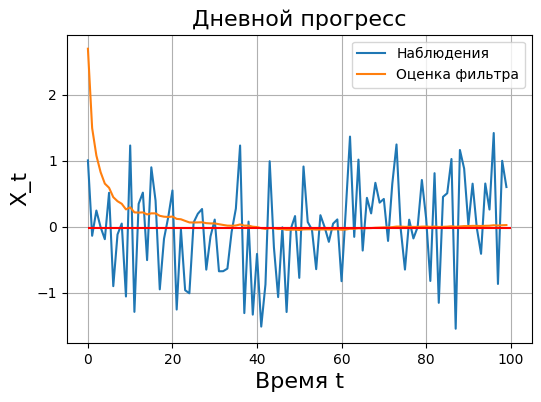

In [ ]:
test_const_filtering(xs, a, 10, sigma1, sigmax)

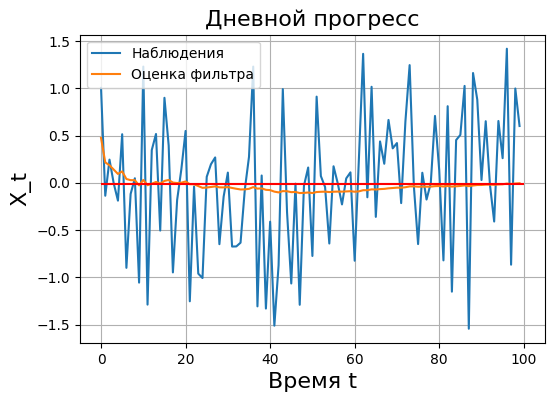

In [ ]:
test_const_filtering(xs, a, mu, 1.5, sigmax)

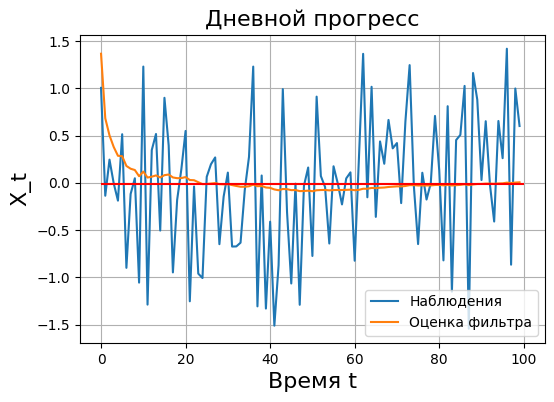

In [ ]:
test_const_filtering(xs, a, 10, 1.5, sigmax)

Да, мы всегда сходимся, но если априорное распределение далеко от истинного, сходимость может занять больше времени. Но можно заметить, что если мы ошибаемся в динамике, то наше апостериорное предсказание тоже будет иметь ненулевое смещение. Попробуйте любой другой ``a=`` и проверьте. Ппопробуйте поменять другие параметры, что изменяется в результате?

Менять только $\mu$ нет особого смысла, так как это будет в основном только влиять на начальное положение.

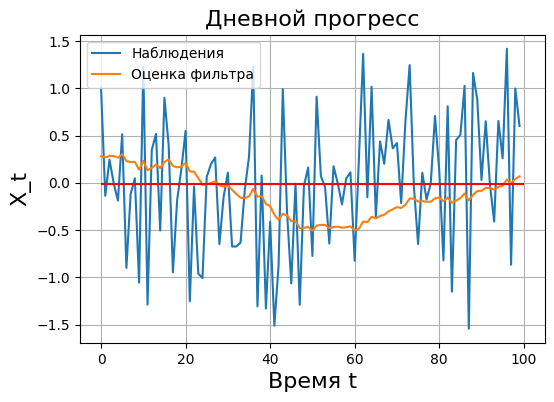

In [ ]:
test_const_filtering(xs, 0.1, mu, sigma1, sigmax)

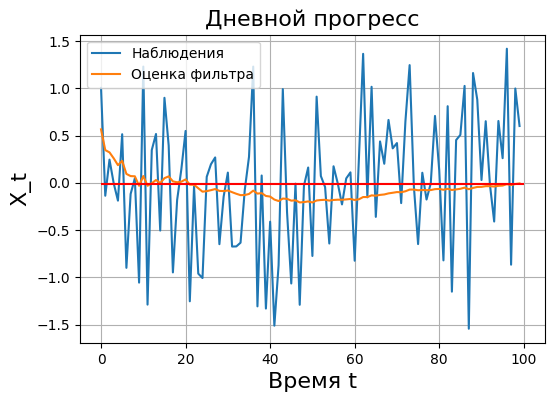

In [ ]:
test_const_filtering(xs, 1, mu, sigma1, sigmax)

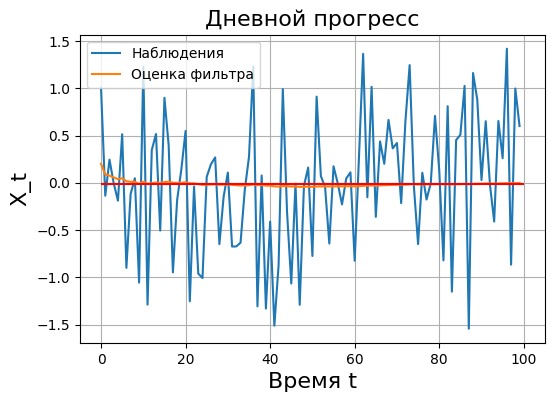

In [ ]:
test_const_filtering(xs, 5, mu, sigma1, sigmax)

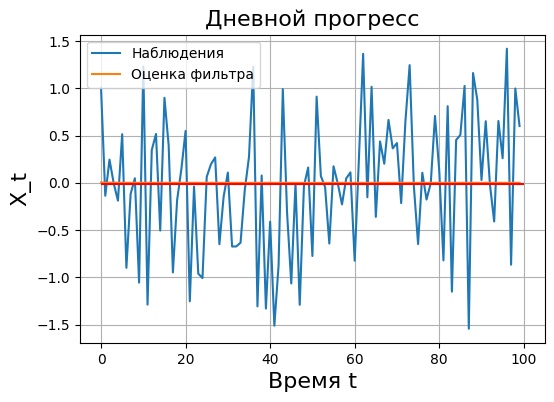

In [ ]:
test_const_filtering(xs, 300, mu, sigma1, sigmax)

При пониженном $a$ график начинает сильно отклоняться от истины. При повышенном ещё пытается сходится.

Посмотрим на формулу P:

при $a \rightarrow \inf $ $P = (1 - a K) P_{t} \rightarrow (1 - 1) * P_{t} = 0$, то есть модель по хорошему должна быть меньше неуверена в своих предсказаниях - оно и видно, график в какой-то момент перестает колебаться, несмотря на то, что значение неверно.

при $a \rightarrow 0 $ наоборот $P = (1 - a K) P_{t} \rightarrow (1 - 0) * P_{t} = P_{t} $, то есть неуверенность почти не будет снижаться с шагами - это тоже видно на графиках, модель будет пытаться отступать от своих предыдущих предсказаний, идет как бы волной.

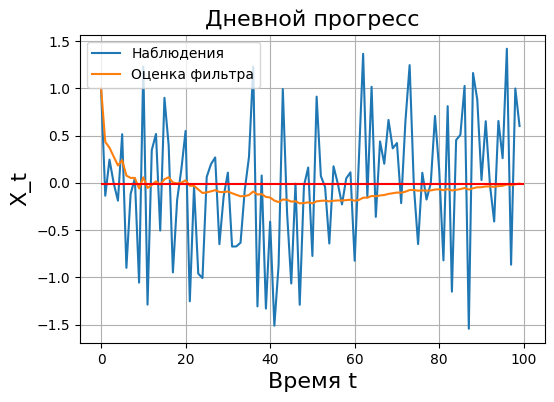

In [ ]:
test_const_filtering(xs, 1, mu, 1e10, sigmax)

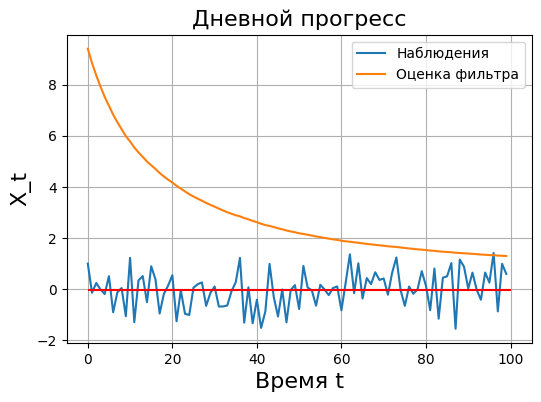

In [ ]:
test_const_filtering(xs, a, 10, 1e-2, sigmax)

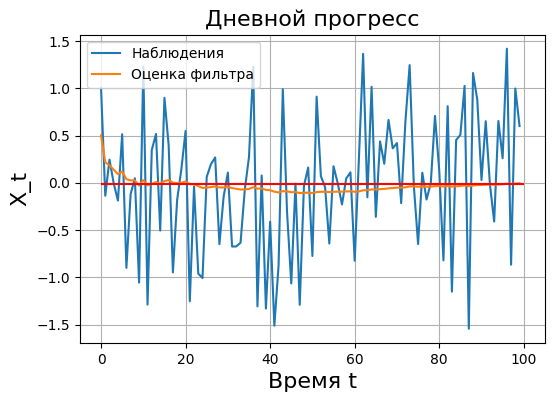

In [ ]:
test_const_filtering(xs, a, mu, sigma1, 0.000001)

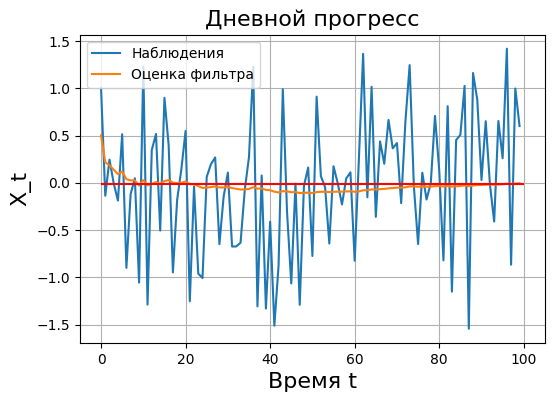

In [ ]:
test_const_filtering(xs, a, mu, 1e10, sigmax)

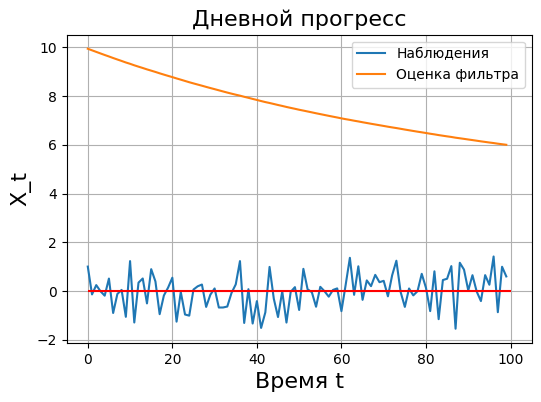

In [ ]:
test_const_filtering(xs, a, 10, 0.001, sigmax)

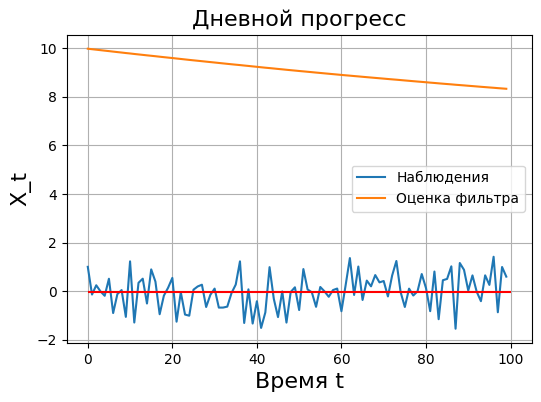

In [ ]:
test_const_filtering(xs, a, 10, sigma1, 1000)

При уменьшении $\sigma_1$ мы становимся более увереными в начальных предсказаниях, значит модель будет довольно сильно зависеть от начального состояния и будет сходится долго. Похожая ситуация с $\sigma_x$.

Вывод: довольно много зависит от гиперпараметров (как и в машинном обучении).

## Фильтр с известным управляющим воздействием (15 баллов)

В предыдущем ДЗ мы уже видели введение известных экзогенных факторов (например, управлений). Учёт таких вещей позволяет существенно лучше строить модель, так как они позволяют лучше понять природу генерации данных.

В этом задании мы напишем простой симулятор робота с упрощённой физической моделью и с геопозиционированием. При этом мы будем полагать, что все параметры известны.

### Модель данных

В традиционную модель мира добавится экзогенный фактор: управление $u_t$. Всё, что про него важно знать -- это в момент $t$ иметь его значение $u_t$. Оно может вообще считаться даже зависимым от $X_t$ (это будет называться управлением с обратной связью, оно может строиться самыми разными способами). Это ничему не противоречит, потому что в момент $t$ величина $X_t$ уже становится известна.

$$
Y_{t+1} = A Y_t + C u_t + V_{t+1}, \quad V_{t} \sim N(0,R_y)
$$

$$
X_{t+1} = B Y_{t+1} + W_{t+1}, \quad W_{t} \sim N(0,R_x)
$$

$$
Y_1 \sim N(\xi, \Lambda).
$$

Априори нам известна матрица $C$, а также матрица $A$, так как есть физическая модель робота. Помимо этого мы знаем матрицу $B$, потому что знаем наши приборы. Иногда мы знаем $R_x$ (из инструкции к замеряющей аппаратуре), но не всегда достаточно точно. $R_y$ почти всегда неизвестно, потому что какова природа шума в динамике, редко известно точно.

Ещё мы можем иногда определить старт $\xi$ с некоторой априорной точностью $\Lambda$.

Теперь о деталях.

Состояние $Y_t$ состоит из 4 переменных: координат $Y^x_t, Y^y_t$ и скоростей $Y^{v_x}_t, Y^{v_y}_t$. При условии отсутствия шума они изменяются по следующему уравнению:

$$
Y^x_t = Y^x_{t-1} + Y^{v_x}_{t-1} \Delta t, \quad  Y^y_t = Y^y_{t-1} + Y^{v_y}_{t-1} \Delta t.  
$$

Скорости изменяются через воздействие со стороны пользователя и с учётом трения (слагаемое с минусом, здесь мы рассматриваем физически нереалистичное линейное трение, надеясь, что оно достаточно малое, чтобы отклоняться от настоящего, которое обычно зависит от квадрата или куба скорости):

$$
Y^{v_x}_t = Y^{v_x}_{t-1} - r Y^{v_x}_{t-1} + c_x u^x_{t-1} \Delta t.
$$

$$
Y^{v_y}_t = Y^{v_y}_{t-1} - r Y^{v_y}_{t-1} + c_y u^y_{t-1} \Delta t .
$$

Здесь $\Delta t$ -- известный заранее шаг по времени, $c_x,c_y$ -- известные заранее константы (хотя их тоже можно пытаться оценивать в рамках ЕМ).

Будем считать, что мы наблюдаем всё несмещённо и идеально: $B=Id$, но при этом с ненулевым шумом с ковариацией $R_x$.


Запишите, как выглядят матрицы $A,B,C$ из уравнений динамики и наблюдения и выпишите полностью модель данных с учётом шума с неизвестной ковариацией.

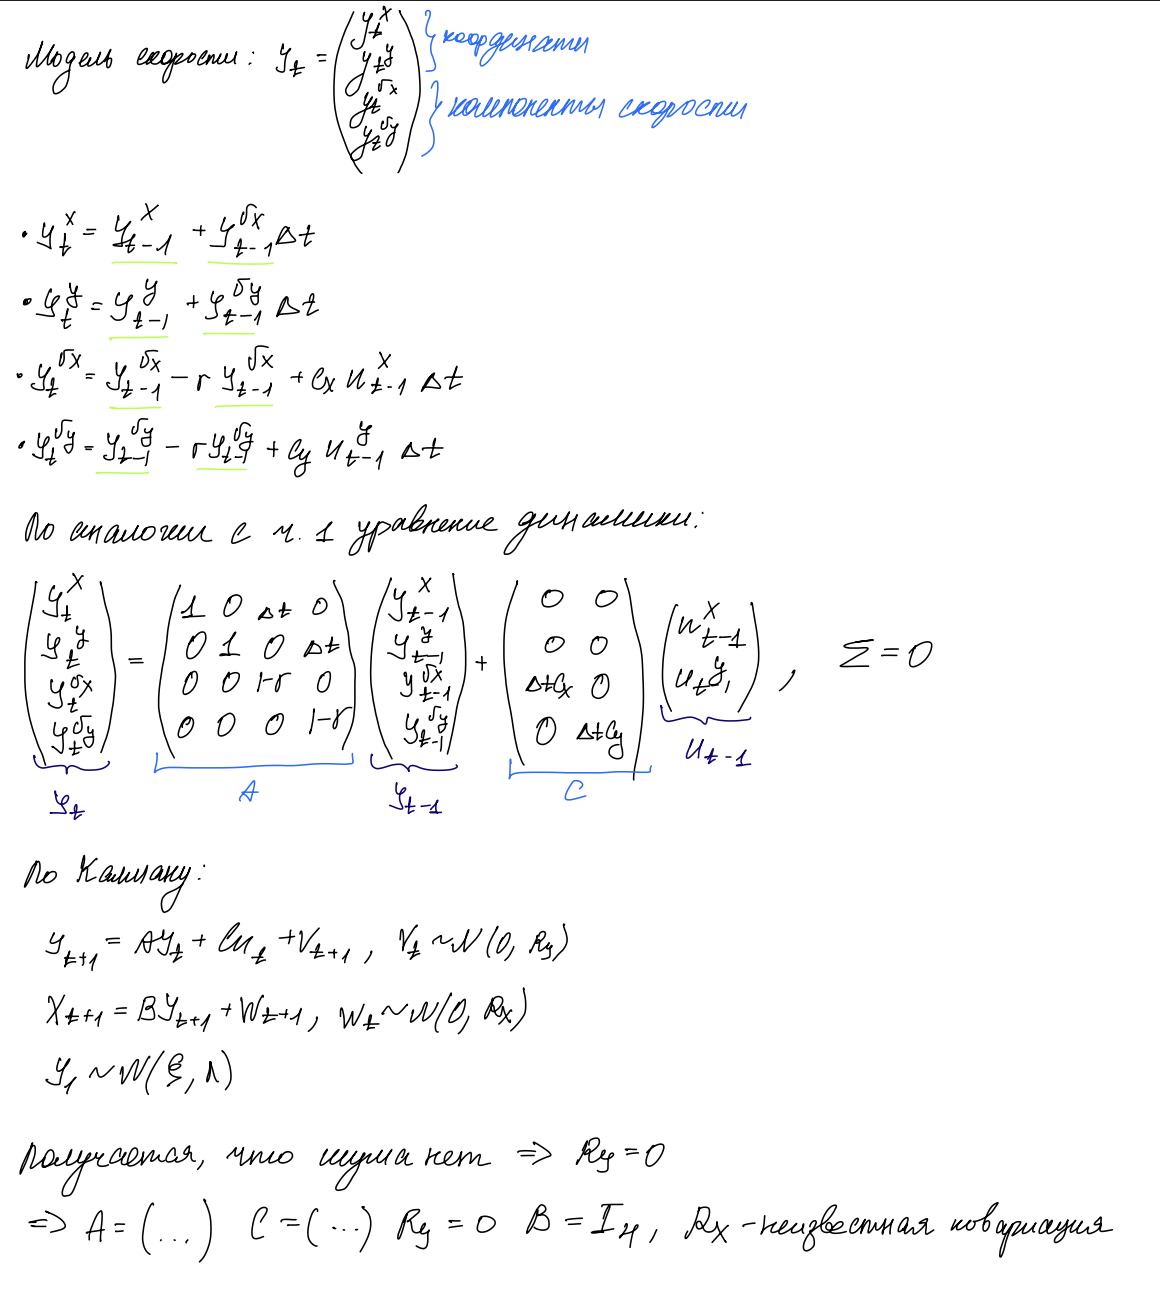

В такой модели немного изменятся уравнения фильтрации, но оказывается, что незначительно. Для того, чтобы это понять, вам потребуется ещё раз просмотреть шаги вывода фильтра Калмана из лекции и посмотреть, где именно и как войдёт управляющее слагаемое $C u_t$.

Выпишите обновлённые уравнения фильтрации и обоснуйте, почему они выглядят так.

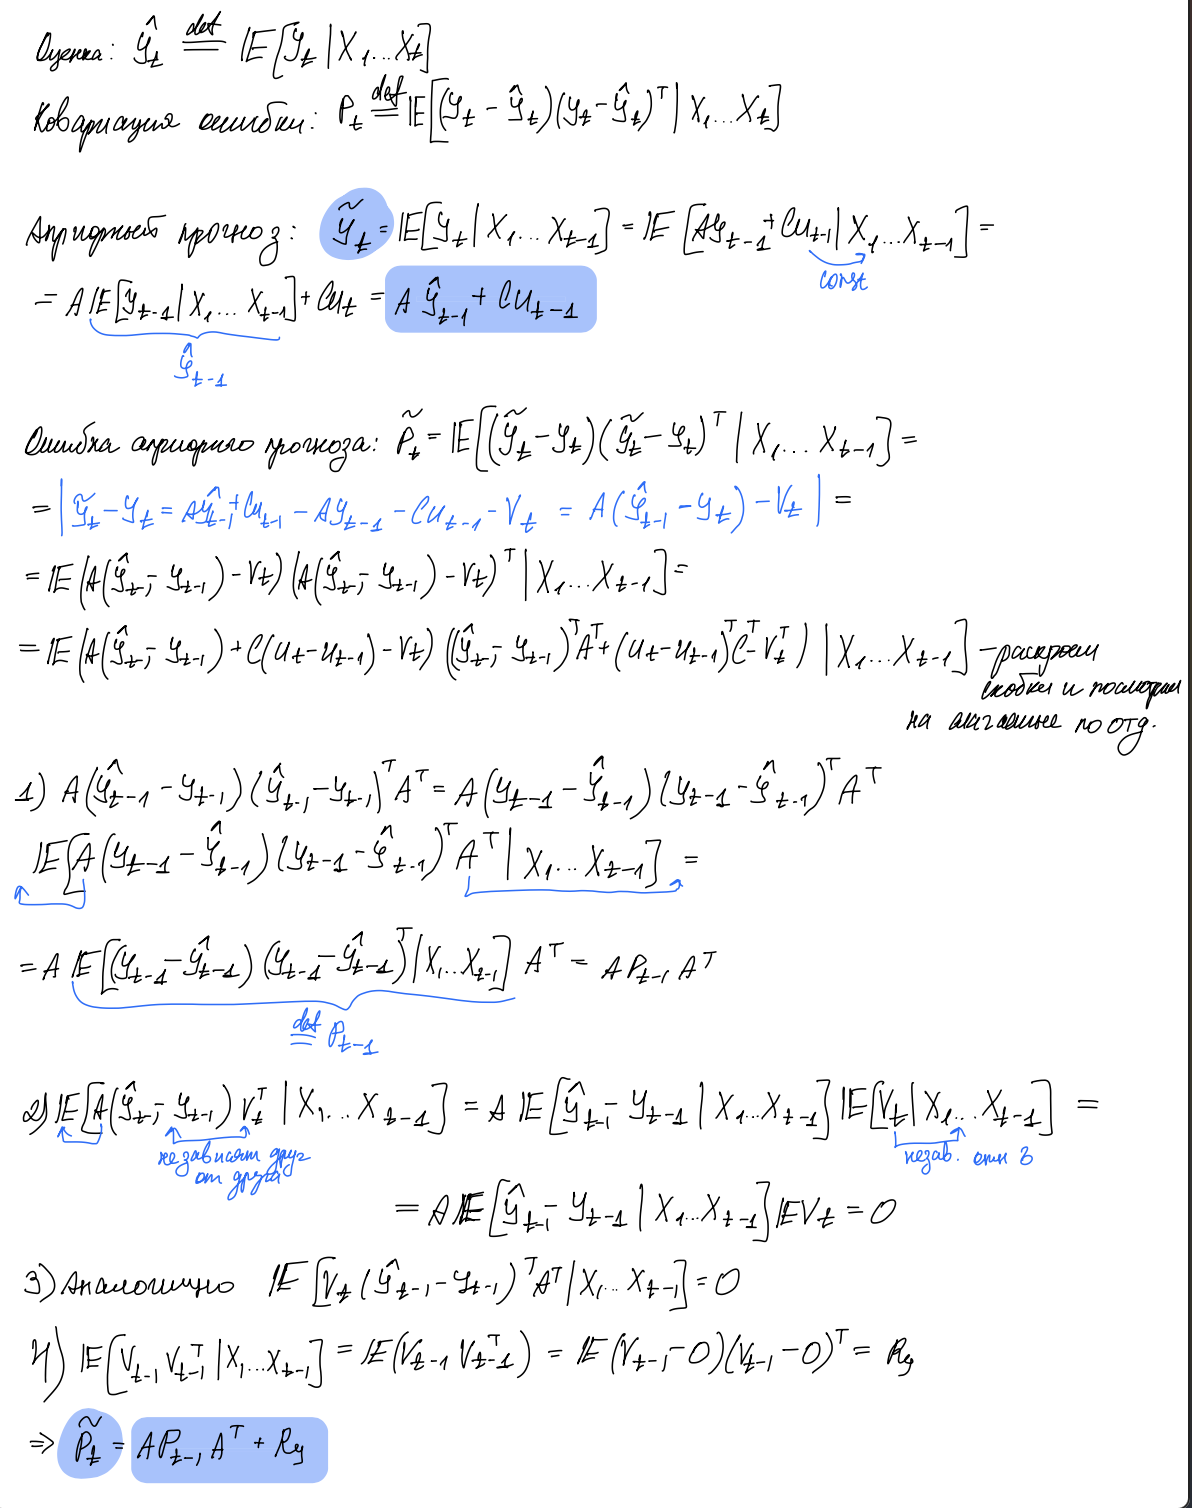

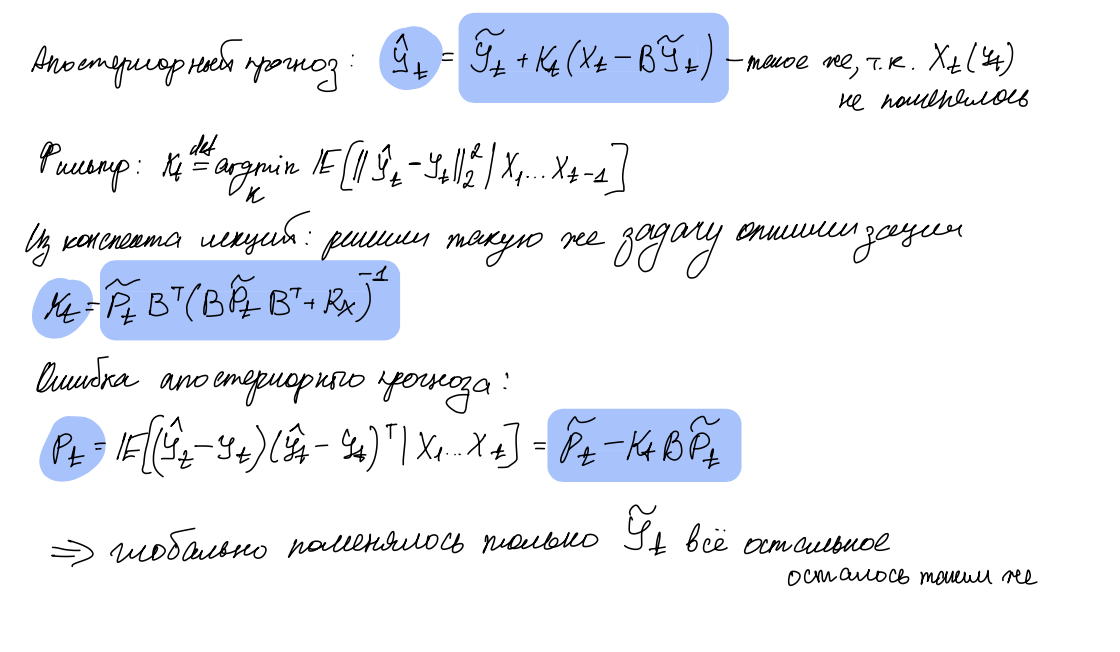

Все кроме априорной оценки осталось таким же, так как $X_t = B Y_t + W_t$, как и в классической модели Калмана, а слагаемое $Cu$ по факту будет менять только априорную оценку, так как у нас смещается матожидание.

### Имплементируем фильтр с учётом управления

На семинарах вы уже видели подготовленную нами библиотеку ``kalmanlib``, которая имплементирует все основные процедуры, связанные с фильтром Калмана.

Ниже приведён её код. Обновите класс так, чтобы управление можно было учесть при проведении фильтрации. Уравнения сглаживания при этом не поменяются, хотя мы явно не просим это доказать.

In [ ]:
class KalmanFilterControlled:

    def __init__(self,A,B,C,Ry,Rx,startMean,startCov):
        """Kalman Filter for Linear Dynamic System of type

        Y(t+1) = AY(t) + U(t),      U(t)  iid  N(0,Ry)    (latent)
        X(t+1) = BY(t+1) + W(t),    W(t)  iid  N(0,Rx)    (observable)
        Y(0) ~ N(startMean, startCov)

        Basically, anything can be estimated but beware of divergence of EM-algorithm.
        Args:
            A (ndarray (d,d) ): dynamics matrix
            B (ndarray (k,d) ): observation matrix
            C (ndarray (d,m)): control matrix
            Ry (ndarray (d,d)): dynamics noise covariance
            Rx (ndarray (k,k)): observation noise covariance
            startMean (ndarray (d,)): dynamics start mean
            startCov (ndarray (d,d)): dynamics start covariance
        """
        self.A = A
        self.B = B
        self.C = C # !!!!!!!!1
        self.Rx = Rx
        self.Ry = Ry
        self.startMean = startMean
        if(startCov is None):
            self.startCov = np.eye(self.A.shape[0])
        else:
            self.startCov = startCov

    def __str__(self):
        return f"KalmanFilter,\n    A=\n    {self.A},\n    B=\n    {self.B},\n    Rx=\n    {self.Rx},\n    Ry=\n    {self.Ry},\n    startCov=\n    {self.startCov},\n    startMean=\n    {self.startMean}"

    def filterStep(self,apostY0,apostErr0,obs, control0=None):
        """Filtering step in Kalman algorithm

        Args:
            apostY0 (ndarray (d,) ): aposteriori prediction from the previous step
            apostErr0 (ndarray (d,d) ): its prediction error covariance
            obs (ndarray (k,) ): the current observation
            control0 (ndarray (m,) ): the control

        Returns:
            aprioriY ndarray (d,): current apriori prediction
            aprioriErr ndarray (d,d): current apriori prediction error covariance
            aposterioriY ndarray (d,): current aposteriori prediction
            aposterioriErr ndarray (d,d): current aposteriori prediction error covariance
            K ndarray (d,k): Kalman gain matrix
        """
        ## YOUR CODE SOMEWHERE, what to change?

        #...................................
        #>..................................

        aprioriY = self.A @ apostY0
        if control0 is not None:
            aprioriY += self.C @ control0

        aprioriErr = self.A @ (apostErr0 @ (self.A.T)) + self.Ry #new apriori error

        K = aprioriErr @ (self.B.T) @ np.linalg.inv(self.Rx + self.B @ aprioriErr @ (self.B.T))# Kalman gain
        #print("GAIN",K)
        aposterioriY = aprioriY + K@(obs - self.B@aprioriY)
        aposterioriErr = aprioriErr - K@self.B@aprioriErr

        return aprioriY,aprioriErr,aposterioriY,aposterioriErr, K

    def filterSignal(self, signal, controls=None, returnK=False):
        """Performs filtration pass

        Args:
            signal (ndarray (d,T) ): observations to filter, X
            controls (ndarray (m,T-1) ): exogenous controls, U. Defaults to None
            returnK (bool, optional): whether to return Kalman gain matrix

        Returns:
            filteredSignal (ndarray (d,T)): filtered(or estimated) signal
            errs (ndarray (d,d,T)): filtered(or estimated) signal error covariance
            aprSignals (ndarray (d,T)): apriori predictions of the signal
            aprErrs (ndarray (d,d,T)): apriori predictions of the signal error covariance
            K (ndarray (d,K)): Kalman gain matrix (if returnK=True)
        """
        ## YOUR CODE SOMEWHERE, what to change?

        #...................................
        #>..................................

        assert signal.shape[0] == self.A.shape[0], 'Expected signal = (d,T)'

        if controls is not None:
            assert signal.shape[1] <= controls.shape[1] + 1, 'Controls must be estimated at least for each step'

        filteredSignal = np.zeros([self.A.shape[0],signal.shape[-1]])
        aprSignals = np.zeros([self.A.shape[0],signal.shape[-1]])
        errs = np.zeros([self.A.shape[0],self.A.shape[0],signal.shape[-1]])
        aprErrs = np.zeros([self.A.shape[0],self.A.shape[0],signal.shape[-1]])
        filteredSignal[:, 0] = self.startMean

        aprSig0 = filteredSignal[:, 0]
        aprErr0 = self.startCov
        errs[:, :, 0] = self.startCov
        aprErrs[:, :, 0] = self.startCov
        aprSignals[:, 0] = self.startMean

        for i in np.arange(1,signal.shape[1]):
            control = None
            if controls is not None:
                control = controls[:, i - 1]
            aprSig, aprErr, apostSig, apostErr, K = self.filterStep(aprSig0, aprErr0, signal[:,i], control)

            aprSig0 = apostSig
            aprErr0 = apostErr

            filteredSignal[:,i] = apostSig
            errs[:,:,i] = apostErr
            aprSignals[:,i] = aprSig
            aprErrs[:,:,i] = aprErr

        if(returnK):
            return filteredSignal, errs, aprSignals, aprErrs, K
        else:
            return filteredSignal, errs, aprSignals, aprErrs

    def smoothSignal(self, filteredSignal, errs, aprSignal, aprErrs, K=None, estLag1=False, returnGains=False):
        """Perfoms smoothing pass given filtering step results

        Args:
            filteredSignal (ndarray (d,T)): filtered(or estimated) signal
            errs (ndarray (d,d,T)): filtered(or estimated) signal error covariance
            aprSignal (ndarray (d,T)): apriori predictions of the signal
            aprErrs (ndarray (d,d,T)): apriori predictions of the signal error covariance
            returnGains (bool, optional): Whether to return smoothing gains

        Returns:
            smoothedSignal (ndarray (d,T)): smoothed signal
            smoothedErrs (ndarray (d,d,T)): smoothed signal error covariance
            gains (list of ndarray): smoothing gains
        """
        #init est
        smoothedSignal = np.zeros_like(filteredSignal)
        smoothedSignal [...,-1] = filteredSignal[...,-1]

        #init cov
        smoothedErrs = np.zeros_like(errs)
        smoothedErrs[...,-1] = errs[...,-1]
        if(estLag1):
            lag1 = np.zeros_like(smoothedErrs)
        if(returnGains):
            gains = []
        for t in np.arange(errs.shape[-1]-2,-1,-1):
            smoothingGain = errs[...,t]@(np.transpose(self.A))@np.linalg.inv(aprErrs[...,t+1])
            if(returnGains):
                gains.append(smoothingGain)
            smoothedSignal[...,t] = filteredSignal[...,t] + \
                smoothingGain@(smoothedSignal[...,t+1]-aprSignal[...,t+1])
            smoothedErrs[...,t] = errs[...,t] + \
                smoothingGain@(smoothedErrs[...,t+1] - aprErrs[...,t+1])@np.transpose(smoothingGain)
            if(estLag1):
                #
                lag1[...,t] =  smoothingGain@smoothedErrs[...,t+1]#

        if(returnGains):
            gains = gains[::-1]
            gains = np.concatenate([gain[:,:,None] for gain in gains], axis=-1)

            if(estLag1):
                return smoothedSignal, smoothedErrs, gains, lag1
            else:
                return smoothedSignal, smoothedErrs, gains
        else:
            if(estLag1):
                return smoothedSignal, smoothedErrs, lag1
            else:
                return smoothedSignal, smoothedErrs



В этом задании нам также понадобится немного обновлённый генератор данных.

In [ ]:
class LinearGaussianControlledSignalGenerator:

    def __init__(self, A, B, C, Ry, Rx,v=1):
        '''
        The model is
        Y_{t+1} = AY_t + C u_t +  V_t (unobservable)
        X_{t+1} = BY_{t+1} + W_t (observable)

        A = (d,d)
        B = ()
        '''
        self.A=A
        self.B=B
        self.C=C
        self.Ry=Ry
        self.Rx=Rx

        #add shape checks here
        assert A.shape[0] == A.shape[1], 'A must be square'
        d = A.shape[0]
        assert C.shape[0] == d, 'Expected C.shape = (d, u)'
        assert Ry.shape[0] == Ry.shape[1] == d, 'Ry must be square'
        assert Rx.shape[0] == Rx.shape[1], 'Rx must be square'
        assert B.shape[1] == d, 'B must be square'
        assert B.shape[0] == Rx.shape[0], 'B and Rx should be in one dimension'

    def generate(self, N, start, feedbackControl):
        '''
        Generates signal and measurements
        int N -- signal length
        float[] start -- start state (Y_0)
        '''

        assert len(start) == self.A.shape[0], f'Expected dimension {self.A.shape[0]}'

        Ys = np.zeros([self.A.shape[0],N]) #signal
        Xs = np.zeros([self.B.shape[0],N]) #measurements
        controls = np.zeros([self.C.shape[1],N-1]) #measurements

        Ys[:,0] = start
        Xs[:,0] = self.measurement(Ys[:,0])


        for i in np.arange(1,N):
            controls[:,i-1] = feedbackControl(Ys[:,i-1])
            Ys[:,i] = self.evolution(Ys[:,i-1], controls[:,i-1] )
            Xs[:,i] = self.measurement(Ys[:,i])

        return Ys, Xs, controls


    def measurement(self, y):
        '''
        Measures the signal
        '''
        return self.B @ y + np.random.multivariate_normal(np.zeros([self.B.shape[0]]), self.Rx)

    def evolution(self, y, control):
        '''
        Updates the signal wrto dynamics
        '''
        return self.A @ y + + self.C @ control + np.random.multivariate_normal(np.zeros([self.A.shape[0]]), self.Ry)

Управление у нас построено так: если робот согласно прибору вылетает за пределы круга заданного радиуса, прилагается управление, чтобы втащить его обратно. Это стабилизирующее управление.

На робота оказывают влияние разные атмосферные факторы, которые влияют на ускорение и, следовательно, зашумляют скорость. Чтобы минимизировать возможные эффекты резонанса при применении управления, добавляется немного гауссовского шума.

In [ ]:
delta = 0.1 #time step
r=0.01 #friction
A = np.array([[1,0,delta,0],[0,1,0,delta],[0,0,1-r,0],[0,0,0,1-r]])
B = np.eye(4)
cx =0.99
cy=0.98
C = np.array([[0,0],[0,0],[cx*delta,0],[0, cy*delta]])
sigv2 = 0.1
Ry = np.array([[1e-15,0,0,0],[0,1e-15,0,0],[0,0,sigv2,0],[0,0,0,sigv2]])
Rx = np.eye(4)*10
generator = LinearGaussianControlledSignalGenerator(A,B,C,Ry,Rx)

startMean = np.array([5,5,0,0])
startCov = np.eye(4)*1e-5

y0 = np.zeros([4])
rad=10
def boundedControl(y):
    normm =np.linalg.norm(y[:2]-y0[:2])
    if (normm >rad):
        return - (20 + np.random.standard_normal()*3 )* (y[:2]-y0[:2]) / normm
    else:
        return 0

Функция ``boundedControl`` представляет собой простейшее наивное управление, призванное стабилизировать систему. Подобные технологии используются в алгоритмах стабилизации, которые в том числе встречаются в программах автопилота в различных системах. Например, нужно порулить лопастями, чтобы вернуть аппарат в стабильное состояние и не разбить об землю.

Конкретно наша задача попадает область построения управлений в [линейных системах с квадратичным критерием (Linear Quadratic Regulator)](https://proceedings.mlr.press/v80/cohen18b/cohen18b.pdf).

In [ ]:
# Сгенерирруйте 500 наблюдений
ys, xs, controls = generator.generate(500, y0, boundedControl)

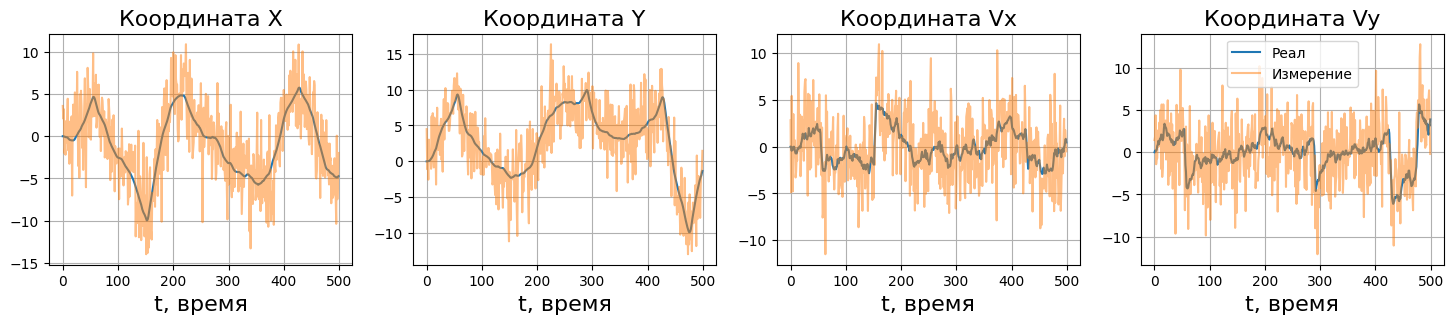

In [ ]:
f, axs = plt.subplots(1,4,figsize=(18,3))

titles=["X","Y","Vx","Vy"]
for i in range(4):
    axs[i].grid()
    axs[i].set_title(f"Координата {titles[i]}",fontsize=16)
    axs[i].set_xlabel(f"t, время",fontsize=16)
    axs[i].plot(ys[i,:])
    axs[i].plot(xs[i,:],alpha=0.5)

axs[-1].legend(["Реал","Измерение"])



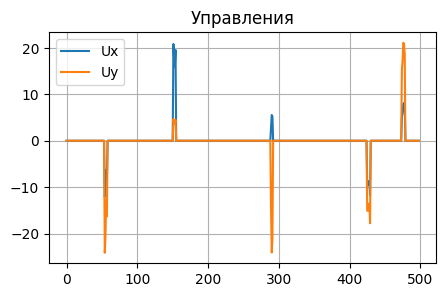

In [ ]:
f,ax = plt.subplots(figsize=(5,3))

ax.grid()
ax.set_title("Управления")
ax.plot(controls[0,:])
ax.plot(controls[1,:])
ax.legend(["Ux","Uy"])

Управление изо всех сил старается удержать робота в начале координат, борясь с эффектами нестабильности, но если продолжить симуляцию, видно, что эта стратегия в долгосрочной перспективе работает плохо.

Можно строить хорошие -- про это наука под названием оптимальное управление, которая идёт рука об руку с алгоритмами фильтрации. Один из подходов может состоять в том, чтобы использовать показания фильтра Калмана в качестве обратной связи (в текущей версии генератора мы идеализированно использовали $Y_t$).

Давайте посмотрим, как фильтр Калмана может помочь нам отфильтровать наблюдения.

In [ ]:
kf = KalmanFilterControlled(A, B, C, Ry, Rx, startMean, startCov)
filteredSignal, errs, aprSignals, aprErrs = kf.filterSignal(xs, controls)
smoothedSignal, smoothedErrs = kf.smoothSignal(filteredSignal, errs, aprSignals, aprErrs)

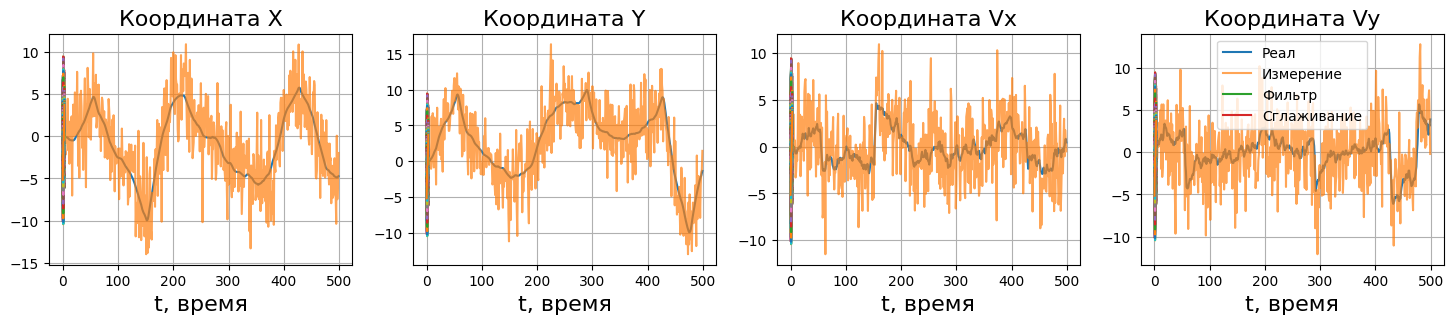

In [ ]:
f, axs = plt.subplots(1,4,figsize=(18,3))

titles=["X","Y","Vx","Vy"]
for i in range(4):
    axs[i].grid()
    axs[i].set_title(f"Координата {titles[i]}",fontsize=16)
    axs[i].set_xlabel(f"t, время",fontsize=16)
    axs[i].plot(ys[i,:])
    axs[i].plot(xs[i,:],alpha=0.7)
    axs[i].plot(filteredSignal)
    axs[i].plot(smoothedSignal)

axs[-1].legend(["Реал","Измерение","Фильтр","Сглаживание"])


В условиях большого шума результаты очень даже хорошие. Посмотрим на разность с истинными значениями, для этого вычтите истинный сигнал $Y_t$ и напечатайте график отклонений. Сравните результат фильтра, сглаживания и оригинальные наблюдения для оценки ненаблюдаемого состояния.

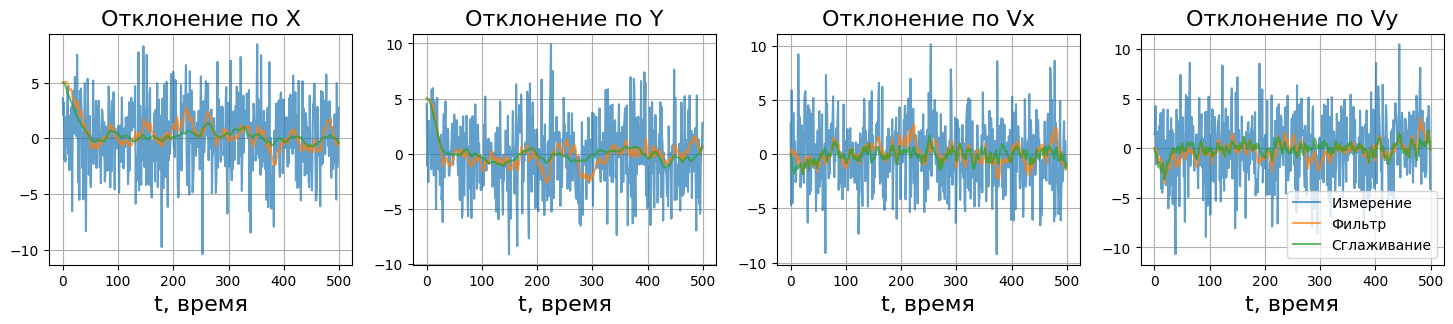

In [ ]:
err_obs = xs - ys
err_filtered = filteredSignal - ys
err_smooth = smoothedSignal - ys

f, axs = plt.subplots(1,4,figsize=(18,3))

titles=["X","Y","Vx","Vy"]
for i in range(4):
    axs[i].grid()
    axs[i].set_title(f"Отклонение по {titles[i]}",fontsize=16)
    axs[i].set_xlabel(f"t, время",fontsize=16)
    axs[i].plot(err_obs[i,:], alpha=0.7)
    axs[i].plot(err_filtered[i,:], alpha=0.7)
    axs[i].plot(err_smooth[i,:], alpha=0.7)

axs[-1].legend(["Измерение","Фильтр","Сглаживание"])

Как видим, сглаживание и фильтр неплохо приближают истинное положение робота. Давайте в этом убедимся еще больше!

Попробуйте нарисовать траекторию робота на плоскости. Приведите на одном графике траектории, соответсвующие

1. Наблюдениям
2. Реальным физическим значениям (ненаблюдаемым)
3. Фильтрованные значения
4. Сглаженные значения

In [ ]:
def plot_path(path, ax, title=''):
    ax.plot(path[0, :], path[1, :])
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

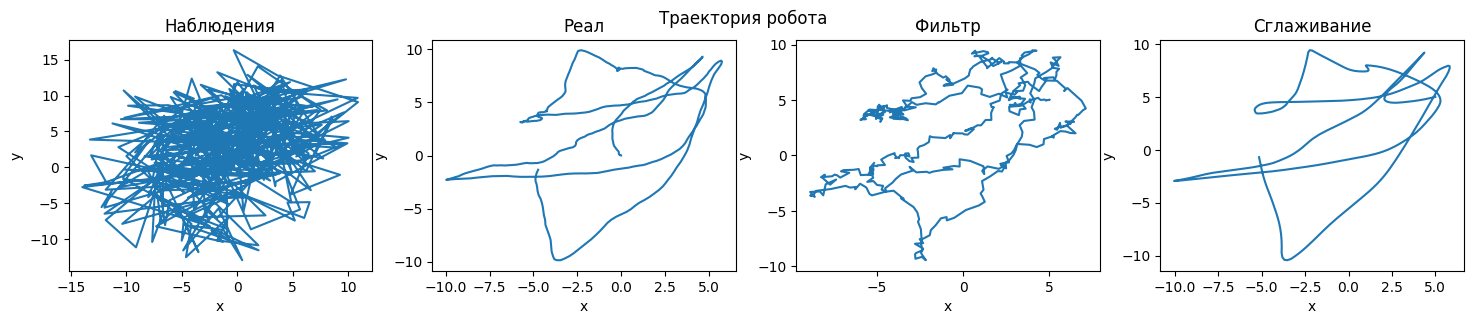

In [ ]:
f, axs = plt.subplots(1,4,figsize=(18,3))
f.suptitle('Траектория робота')

plot_path(xs, axs[0], 'Наблюдения')
plot_path(ys, axs[1], 'Реал')
plot_path(filteredSignal, axs[2], 'Фильтр')
plot_path(smoothedSignal, axs[3], 'Сглаживание')

plt.tight_layout()
plt.show()

Насколько фильтр справляется с задачей?

Слушайте, фильтр Калмана молодец! Я считаю, он очень хорошо приблизил истинный путь робота. Есть конечно какие-то артефакты, но по сравнению с наблюдениями это всяко лучше и можно использовать на практике. Конечно, можно пытаться довести до идеала и подбирать гиперпараметры.

## Детектив (25 баллов)

Наш семинарист Алексей глубоко погружен в любительский автоспорт и интерактивные гонки. Его автоспортивные коллеги поделились данными телеметрии гоночного автомобиля Toyota Yaris GR, который проехал несколько кругов по трассе [Monteblanco](https://en.wikipedia.org/wiki/Circuito_Monteblanco) на юге Испании . На автомобиль был установлен датчик Racebox micro, который замеряет и передает данные телеметрии (геопозицию, скорости, ускорения, технические характеристики типа температуры масла и т.п.). в мобильное приложение RaceChrono, откуда датасет и был экспортирован.

По стечению обстоятельств при экспорте данные заметно исказились и сократились. Перед вами стоит задача используя фильтр Калмана и искаженный датасет примерно оценить форму гоночной трассы, по которой ехал гоночный автомобиль.

Чтобы дать вам понять, насколько вы можете быть близки, вот фото реального трека, на котором была записана телеметрия и [видео заезда](https://youtu.be/2BGPAwQ19Nc?si=jhnUuf_aKLmP_6EN), отраженного в исходном датасете.

![image.png](attachment:image.png)

## Модель

В данных присутствуют координаты (зашумлённые) и ускорения (посчитанные по телеметрии с учётом физической модели конкретного автомобиля, с очень хорошей точностью). [Вот пример](http://www.icicel.org/ell/contents/2016/8/el-10-08-12.pdf), как про это думают, здесь не обойтись без нелинейной фильтрации.

В данных вам даны ускорения, поэтому самая сложная часть оценивания по сути решена и нам остаётся линейная модель по типу той, что мы рассматривали выше. Запишите ниже уравнения динамики и наблюдений, указав все матрицы $A,B,C,R_x,R_y,\xi,\Lambda$ и пояснив, как там есть физические величины (если есть).

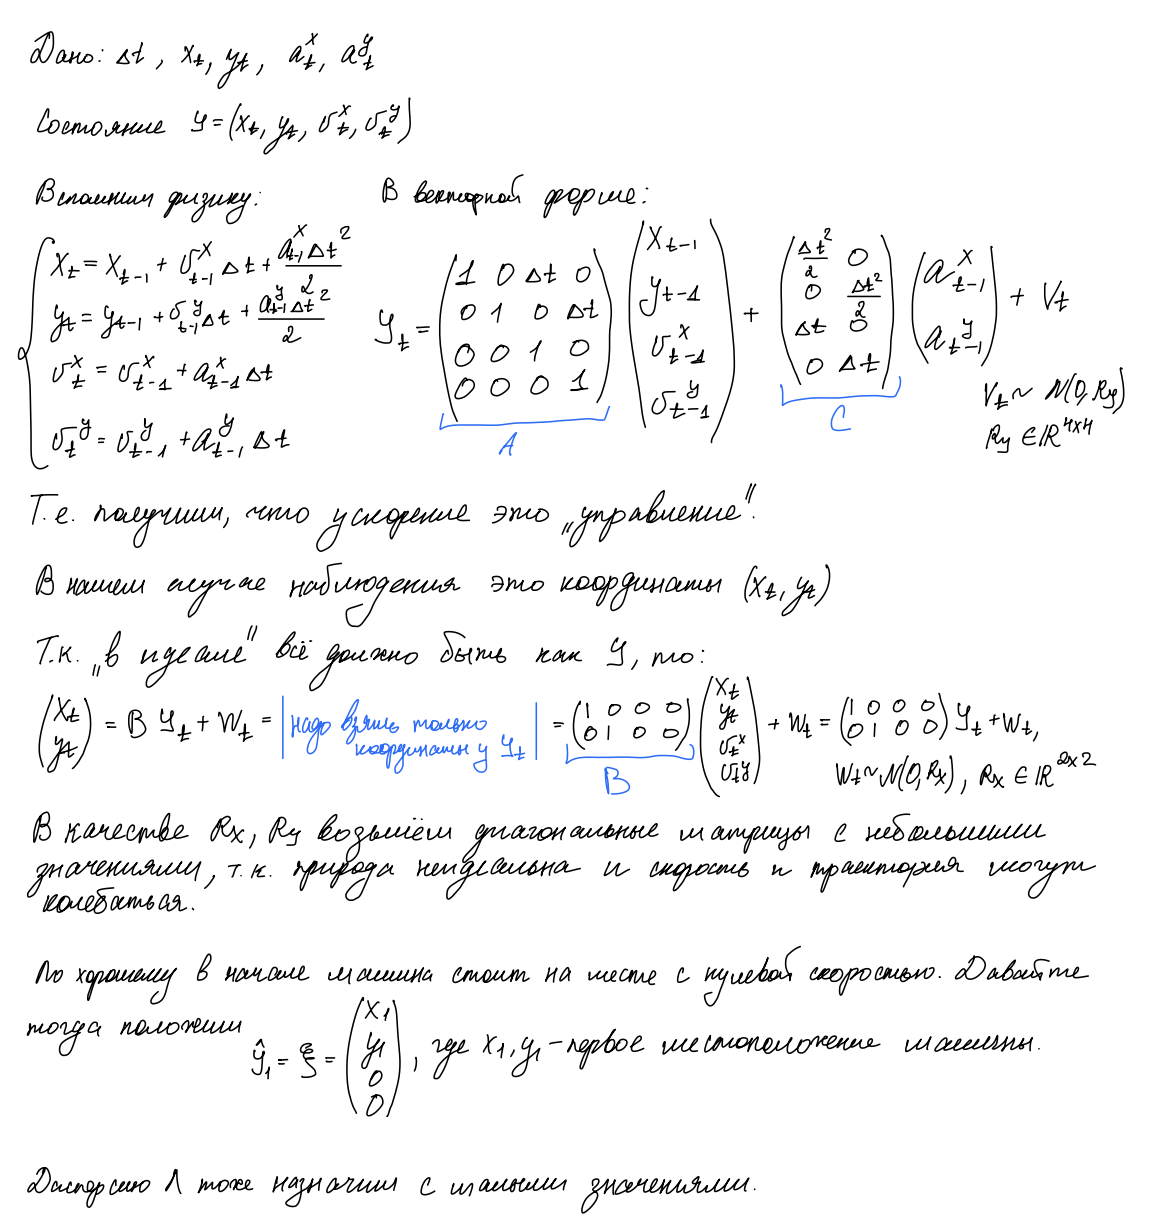

Теперь загрузим данные и приступим к иузчению.

### Фильтрация

Данные в файле ``raceCorrupted.pickle`` предстваляют собой 4 координаты и время:

- ``timestamp``: относительное время в секундах от начала записи (в секундах).
- ``latitude``: относительная широта в метрах (широта с вычетом одной из точек и переведённая из градусов (GPS) в метрические единицы).
- ``longitude``: относительная долгота в метрах (широта с вычетом одной из точек и переведённая из градусов (GPS) в метрические единицы).
- ``lat_acc``: ускорение по широте (в м/сек^2)
- ``long_acc``: ускорение по долготе (в м/сек^2)

Машина проехала несколько кругов по трассе.

Загрузите датасет и напечатайте наблюдения в осях  (``longitude`` , ``latitude``), а также сами ряды координат и ускорений.

In [ ]:
with open('raceCorrupted.pickle', 'rb') as f:
    race_data = pickle.load(f)
race_data

{'latitude': array([ 177.64536212,   19.85214464, -138.40415124, ...,  142.98061523,
          80.32973489,  169.68091029], shape=(12032,)),
 'longitude': array([  51.91507556, -142.16623016,  135.19450307, ..., -361.75044488,
        -331.01252435, -310.60466055], shape=(12032,)),
 'timestamp': array([0.00000000e+00, 2.00009346e-03, 1.99999809e-02, ...,
        2.30820000e+02, 2.30840000e+02, 2.30870000e+02], shape=(12032,)),
 'lat_acc': array([-0.292824, -0.293706, -0.301742, ..., -0.115836, -0.117012,
        -0.118874], shape=(12032,)),
 'long_acc': array([ 1.881208,  1.880032,  1.869644, ..., -2.737924, -2.751448,
        -2.771832], shape=(12032,))}

In [ ]:
ts = race_data['timestamp']
ts[1:] - ts[:-1]

array([0.00200009, 0.01799989, 0.01999998, ..., 0.0059998 , 0.02000022,
       0.02999997], shape=(12031,))

In [ ]:
race_data['long_acc'].shape

(12032,)

Так как тут изменения во времени все время разные, то придется на каждом шагу менять матрицы A и C, но глобально алгоритм не поменяется. Все преобразования в доказательстве алгоритма зависели только от конкретного шага, поэтому нам неважно.

С Вашего позволения я напишу свои функции, мне так удобнее.

In [ ]:
class KalmanFilterRace:

    def __init__(self, lat, lon, ts, lat_acc, lon_acc):
        self.lat = lat
        self.lon = lon
        self.ts = ts
        self.lat_acc = lat_acc
        self.lon_acc = lon_acc

        self.A = np.eye(4)
        self.B = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]])
        self.C = np.zeros((4, 2))
        self.Ry = np.eye(4) * 5e-10
        self.Rx = np.eye(2) * 1e-5

        self.start_mean = np.array([lon[0], lat[0], 0, 0])
        self.start_cov = np.eye(4) * 1e-5

    def filterStep(self, apostY0, apostErr0, obs, control0=None):
        """Filtering step in Kalman algorithm

        Args:
            apostY0 (ndarray (d,) ): aposteriori prediction from the previous step
            apostErr0 (ndarray (d,d) ): its prediction error covariance
            obs (ndarray (k,) ): the current observation
            control0 (ndarray (m,) ): the control

        Returns:
            aprioriY ndarray (d,): current apriori prediction
            aprioriErr ndarray (d,d): current apriori prediction error covariance
            aposterioriY ndarray (d,): current aposteriori prediction
            aposterioriErr ndarray (d,d): current aposteriori prediction error covariance
            K ndarray (d,k): Kalman gain matrix
        """
        ## YOUR CODE SOMEWHERE, what to change?

        #...................................
        #>..................................

        aprioriY = self.A @ apostY0
        if control0 is not None:
            aprioriY += self.C @ control0

        aprioriErr = self.A @ (apostErr0 @ (self.A.T)) + self.Ry # new apriori error

        K = aprioriErr @ (self.B.T) @ np.linalg.inv(self.Rx + self.B @ aprioriErr @ (self.B.T)) # Kalman gain
        aposterioriY = aprioriY + K @ (obs - self.B @ aprioriY)
        aposterioriErr = aprioriErr - K @ self.B @ aprioriErr

        return aprioriY,aprioriErr,aposterioriY,aposterioriErr, K

    def filterSignal(self, returnK=False):
        """Performs filtration pass

        Args:
            signal (ndarray (d,T) ): observations to filter, X
            controls (ndarray (m,T-1) ): exogenous controls, U. Defaults to None
            returnK (bool, optional): whether to return Kalman gain matrix

        Returns:
            filteredSignal (ndarray (d,T)): filtered(or estimated) signal
            errs (ndarray (d,d,T)): filtered(or estimated) signal error covariance
            aprSignals (ndarray (d,T)): apriori predictions of the signal
            aprErrs (ndarray (d,d,T)): apriori predictions of the signal error covariance
            K (ndarray (d,K)): Kalman gain matrix (if returnK=True)
        """
        ## YOUR CODE SOMEWHERE, what to change?

        #...................................
        #>..................................

        filteredSignal = np.zeros([self.A.shape[0], self.lat.shape[0]])
        aprSignals = np.zeros([self.A.shape[0], self.lat.shape[0]])
        errs = np.zeros([self.A.shape[0], self.A.shape[0], self.lat.shape[0]])
        aprErrs = np.zeros([self.A.shape[0], self.A.shape[0], self.lat.shape[0]])
        filteredSignal[:, 0] = self.start_mean

        aprSig0 = filteredSignal[:, 0]
        aprErr0 = self.start_cov
        errs[:, :, 0] = self.start_cov
        aprErrs[:, :, 0] = self.start_cov
        aprSignals[:, 0] = self.start_mean

        for i in np.arange(1, self.lat.shape[0]):
            signal = np.array([self.lon[i], self.lat[i]])

            control = np.array([self.lon_acc[i - 1], self.lat_acc[i - 1]])

            delta_time = self.ts[i] - self.ts[i - 1]
            self.A[0, 2] = delta_time
            self.A[1, 3] = delta_time
            self.C[0, 0] = delta_time * delta_time / 2
            self.C[1, 1] = delta_time * delta_time / 2
            self.C[2, 0] = delta_time
            self.C[3, 1] = delta_time

            aprSig, aprErr, apostSig, apostErr, K = self.filterStep(aprSig0, aprErr0, signal, control)

            aprSig0 = apostSig
            aprErr0 = apostErr

            filteredSignal[:,i] = apostSig
            errs[:,:,i] = apostErr
            aprSignals[:,i] = aprSig
            aprErrs[:,:,i] = aprErr

        if(returnK):
            return filteredSignal, errs, aprSignals, aprErrs, K
        else:
            return filteredSignal, errs, aprSignals, aprErrs

    def smoothSignal(self, filteredSignal, errs, aprSignal, aprErrs, K=None, estLag1=False, returnGains=False):
        """Perfoms smoothing pass given filtering step results

        Args:
            filteredSignal (ndarray (d,T)): filtered(or estimated) signal
            errs (ndarray (d,d,T)): filtered(or estimated) signal error covariance
            aprSignal (ndarray (d,T)): apriori predictions of the signal
            aprErrs (ndarray (d,d,T)): apriori predictions of the signal error covariance
            returnGains (bool, optional): Whether to return smoothing gains

        Returns:
            smoothedSignal (ndarray (d,T)): smoothed signal
            smoothedErrs (ndarray (d,d,T)): smoothed signal error covariance
            gains (list of ndarray): smoothing gains
        """
        #init est
        smoothedSignal = np.zeros_like(filteredSignal)
        smoothedSignal [...,-1] = filteredSignal[...,-1]

        #init cov
        smoothedErrs = np.zeros_like(errs)
        smoothedErrs[...,-1] = errs[...,-1]
        if(estLag1):
            lag1 = np.zeros_like(smoothedErrs)
        if(returnGains):
            gains = []
        for t in np.arange(errs.shape[-1] - 2, -1, -1):
            delta_time = self.ts[i + 1] - self.ts[i]
            self.A[0, 2] = delta_time
            self.A[1, 3] = delta_time
            self.C[0, 0] = delta_time * delta_time / 2
            self.C[1, 1] = delta_time * delta_time / 2
            self.C[2, 0] = delta_time
            self.C[3, 1] = delta_time

            smoothingGain = errs[...,t]@(np.transpose(self.A))@np.linalg.inv(aprErrs[...,t+1])
            if(returnGains):
                gains.append(smoothingGain)
            smoothedSignal[...,t] = filteredSignal[...,t] + \
                smoothingGain@(smoothedSignal[...,t+1]-aprSignal[...,t+1])
            smoothedErrs[...,t] = errs[...,t] + \
                smoothingGain@(smoothedErrs[...,t+1] - aprErrs[...,t+1])@np.transpose(smoothingGain)
            if(estLag1):
                #
                lag1[...,t] =  smoothingGain@smoothedErrs[...,t+1]#

        if(returnGains):
            gains = gains[::-1]
            gains = np.concatenate([gain[:,:,None] for gain in gains], axis=-1)

            if(estLag1):
                return smoothedSignal, smoothedErrs, gains, lag1
            else:
                return smoothedSignal, smoothedErrs, gains
        else:
            if(estLag1):
                return smoothedSignal, smoothedErrs, lag1
            else:
                return smoothedSignal, smoothedErrs



In [ ]:
kf = KalmanFilterRace(race_data['latitude'], race_data['longitude'], race_data['timestamp'], race_data['lat_acc'], race_data['long_acc'])
filteredSignal, errs, aprSignals, aprErrs = kf.filterSignal()
smoothedSignal, smoothedErrs = kf.smoothSignal(filteredSignal, errs, aprSignals, aprErrs)

Приведите график в осях (``longitude`` , ``latitude``), на котором показаны наблюдения и ваш рисунок трассы. Опишите и обоснуйте ваш подход к решению.

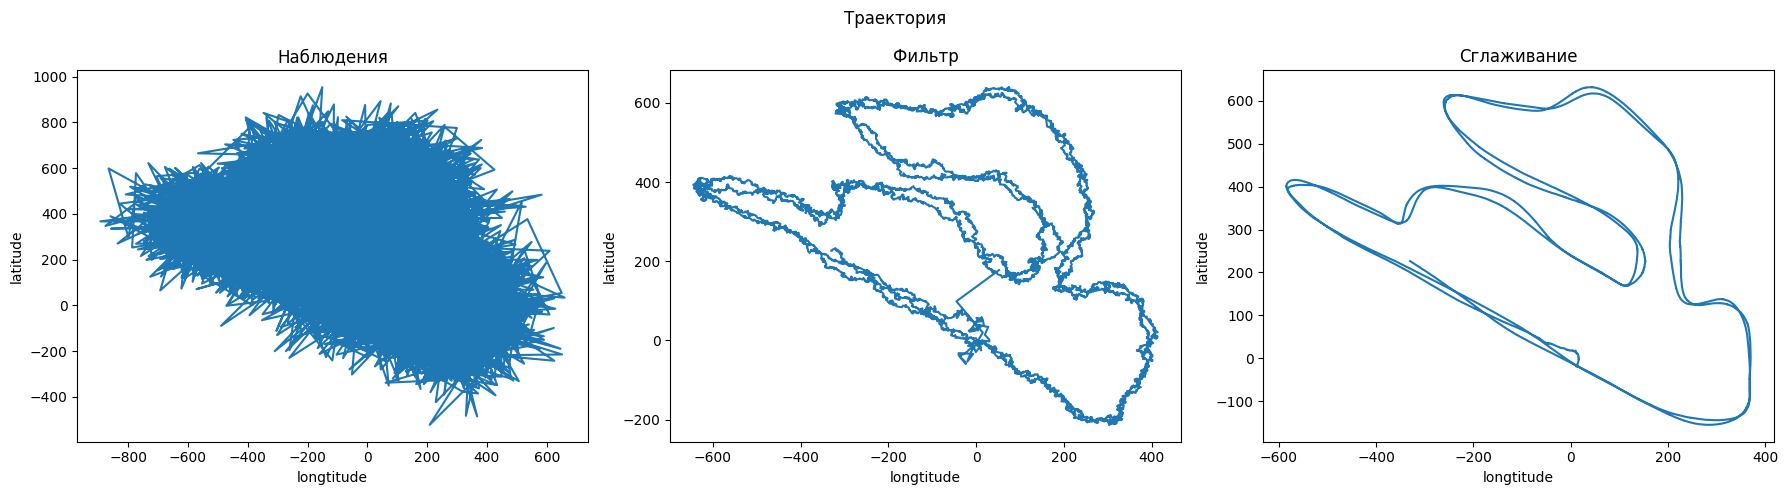

In [ ]:
f, axs = plt.subplots(1,3,figsize=(18,5))
f.suptitle('Траектория')

plot_path(np.array([kf.lon, kf.lat]), axs[0], 'Наблюдения')
plot_path(filteredSignal, axs[1], 'Фильтр')
plot_path(smoothedSignal, axs[2], 'Сглаживание')
for i in range(3):
    axs[i].set_xlabel('longtitude')
    axs[i].set_ylabel('latitude')

plt.tight_layout()

Изначально, мы не знаем ни ускорения, ни углов наклона и тд. В то же время положение машины в момент времени напрямую зависит от координаты и ускорения. В статье авторы рассматривают особый подход, в котором мы полагаем какие-то дополнительные неизвестные параметры. В данной задаче это ускорения. Значи по-хорошему нам надо пытаться восстановить нечто другое и использовать другие скрытые параметры. Однако авторы задачи сказали, что они вычислены (оценены) точно, значит можно применить вероятностный подход и оценить модель линейно. Дополнительно учел слагаемое с ускорением в изменении координаты.

Получили почти точную копию стадиона. Ура! К тому же итоговая траектория ещё и показывает, что движение машины по кругу неточно.

В процессе я экспериментировал с гиперпараметрами Rx, Ry и картинки то были очень похожи, то непохожи вовсе. Поэтому тут можно пытаться долго разбираться.

Я ещё дополнительно поменял координаты местами, чтобы сравнивать было просто проще, однако априори мы это не знаем, НО это несложно меняется перестановкой координат внутри модели.